## Seung Jun Choi in Urban Information Lab
### Introducting PyTorch

#### https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

### Previously, we only used Keras/TensorFlow and Sckit-learn

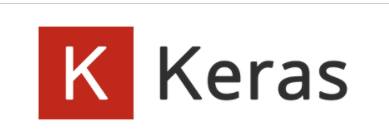

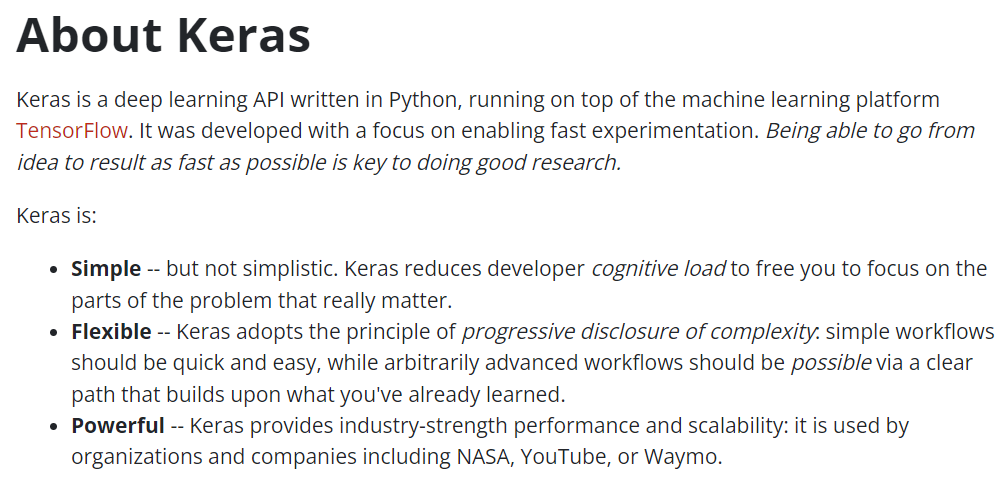

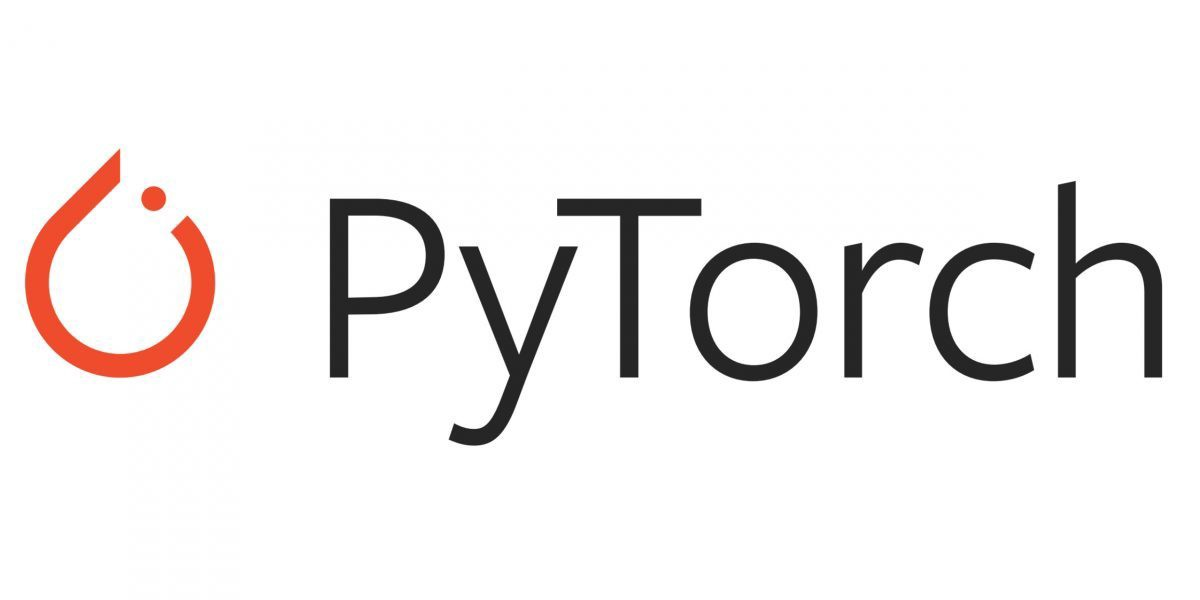

## What is PyTorch?
### PyTorch is an open-source library used in machine learning developed using the Torch library for Python. It was developed by Facebook’s AI Research lab and released in January 2016. It is primarily used in computer vision, deep learning, and natural language processing applications.

## Why do we need PyTorch?

### The PyTorch framework can be seen as the future of the deep learning framework. There are many deep learning frameworks, but PyTorch is emerging as a winner due to its flexibility and computational power. For machine learning and Artificial Intelligence enthusiasts, PyTorch is easy to learn and will be very useful to build models.

### Developers tend to prefer PyTorch because it fits in both GPU and CPU environments

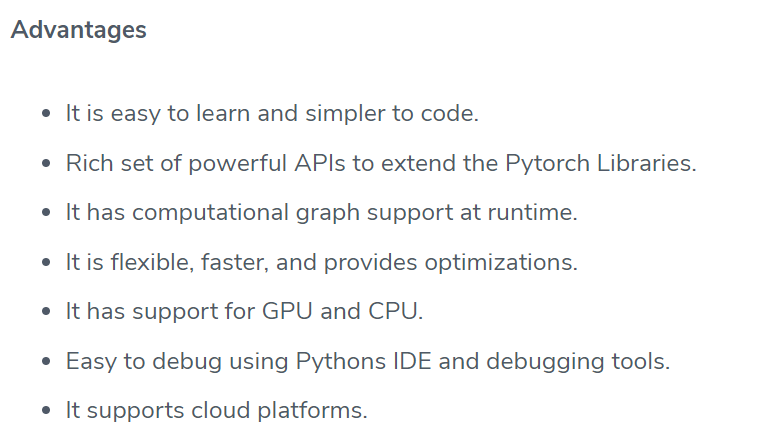

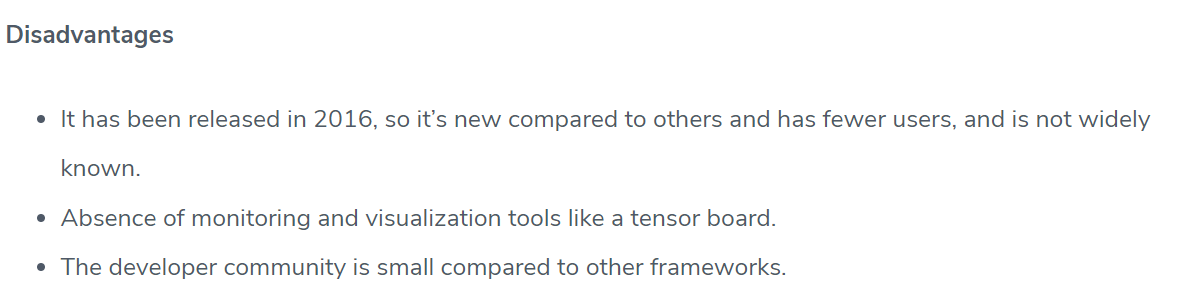

## Examples of Keras and PyTorch models

<span style='font-size:18px;'>
The code snippets below give a little taste of the differences between the two frameworks. <br><br>
    
Model training requires around 20 lines of code in PyTorch, compared to a single line in Keras.<br><br>
Enabling GPU acceleration is handled implicitly in Keras, while PyTorch requires us to specify when to transfer data between the CPU and GPU.<br><br>
Despite the fact that Keras is slightly simpler than PyTorch, it’s a serious deep learning tool used by beginners and seasoned data scientists alike.
</span>

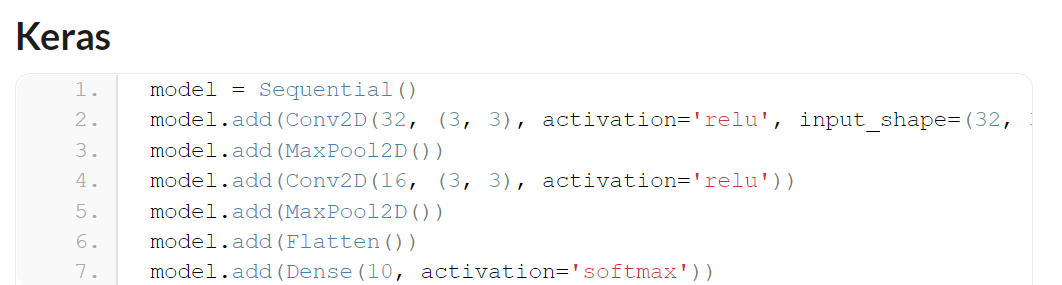

*(example model, not runnable code)*

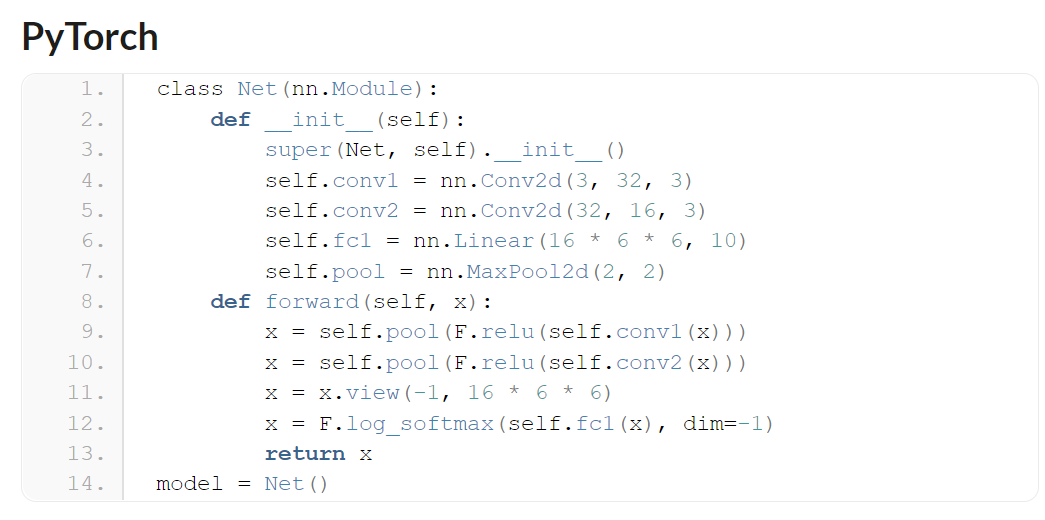

*(example model, not runnable code)*

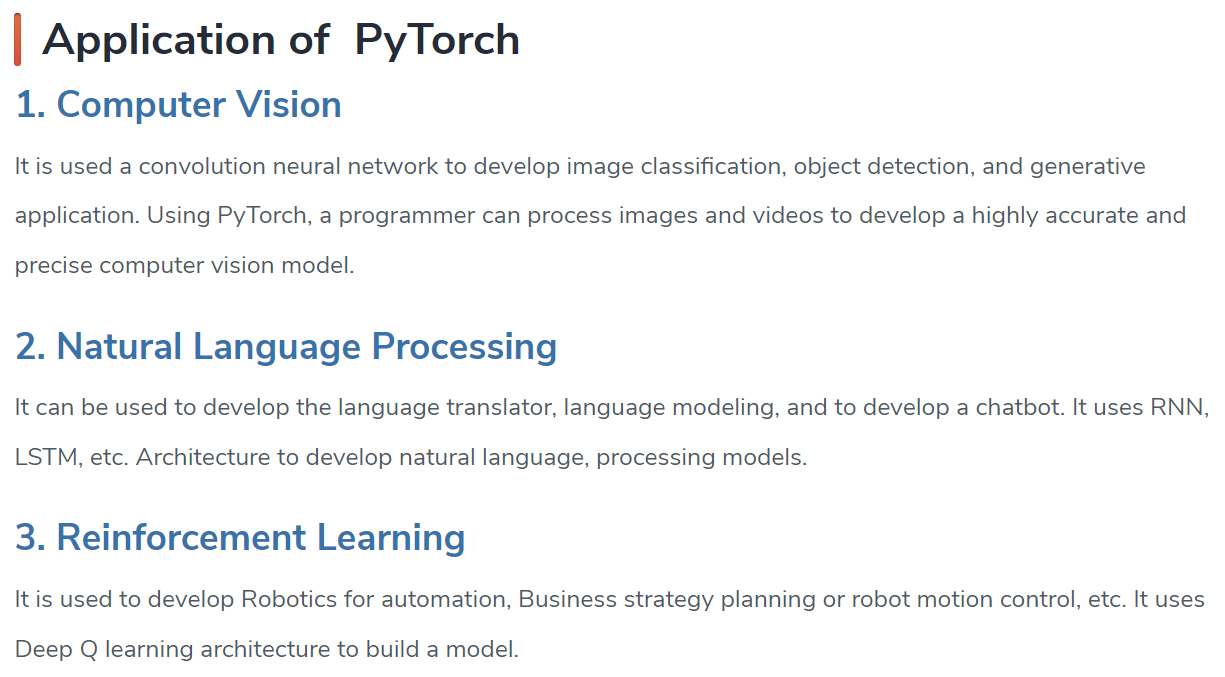

### PyTorch has a similar syntax to other standard programming languages, so it is easy to learn. 

## We’ll build a neural network to classify images in the FashionMNIST dataset.

### We will also introduce the pre-defined modules in PyTorch

### Before digging in further, please pip install torch & torchvision. This will take some time.

In [5]:
# If necessary, install: 
#!pip install torch
#!pip install torchvision

import sys
import os
import torch
import torchvision
import numpy as np

print(f'Python version: {sys.version}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')
print(f'numpy version: {np.__version__}')

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
numpy version: 1.26.4


<span style='font-size:18px;'>
We want to be able to train our model on a hardware accelerator like a GPU, if available. 

Let’s check to see if torch.cuda is available, else we continue to use the CPU.
</span>

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cpu device


MIne is CPU (Sadly)

## Define the Class

<span style='font-size:18px;'>PyTorch defines a neural network by subclassing nn.Module, and initialize the neural network layers in <code>__init__</code>. <br><br>
Every nn.Module subclass implements the operations on input data in the forward method.</span>

In [8]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__() 
        # can also do super().__init()
        self.flatten = nn.Flatten() # changes the shape of the tensor
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512), # linear layer, 28*28 features in, 512 features out
            nn.ReLU(), # relu nonlinearity
            nn.Linear(512, 512), # linear layer, 512 in, 512 out
            nn.ReLU(), # relu nonlinearity
            nn.Linear(512, 10), # linear layer, 512 in, 10 out
        )

    def forward(self, x):
        x = self.flatten(x) # the nn.Flatten() function applied to x
        logits = self.linear_relu_stack(x) # pass through feedforward layers
        return logits # raw output logits for each class (10 classes)

## Create an instance of our NeuralNetwork class, move it to the device (CPU or GPU) and print its structure

In [9]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


## To use the model, we pass it the input data
<span style='font-size:18px;'>This executes the model’s forward, along with some background operations.<br><br>
**Do not call model.forward() directly!** <br><br>
Calling the model on the input returns a 10-dimensional tensor with raw predicted values for each class.<br><br>
We get the prediction probabilities by passing the logits through an instance of the nn.Softmax module.</span>

In [14]:
X = torch.rand(1, 28, 28, device=device)  
# tensor of random numbers (between 0 and 1) 
# data (X) is on the same device as the model (important if you are using GPU)
print(f'Shape of tensor X: {X.shape}')

logits = model(X)
print(f'\nThese are the raw logits:\n{logits}')

pred_probab = nn.Softmax(dim=1)(logits)
print(f'\nApplying softmax to the logits converts them to probabilities:\n{pred_probab}')

y_pred = pred_probab.argmax(1) # predicted class is the class with the highest probability
print(f"\nPredicted class: {y_pred}")

Shape of tensor X: torch.Size([1, 28, 28])

These are the raw logits:
tensor([[-0.0053,  0.0520,  0.0519,  0.0159, -0.0007, -0.0585, -0.0258,  0.0347,
         -0.0155,  0.0497]], grad_fn=<AddmmBackward0>)

Applying softmax to the logits converts them to probabilities:
tensor([[0.0984, 0.1042, 0.1042, 0.1005, 0.0989, 0.0933, 0.0964, 0.1025, 0.0974,
         0.1040]], grad_fn=<SoftmaxBackward0>)

Predicted class: tensor([1])


## Model Layers
<span style='font-size:18px;'>Let’s break down the layers in the FashionMNIST model.<br><br>
To illustrate it, we will take a sample minibatch of 3 images of size 28x28 and see what happens as we pass it through the network.</span>

torch.Size([3, 28, 28])


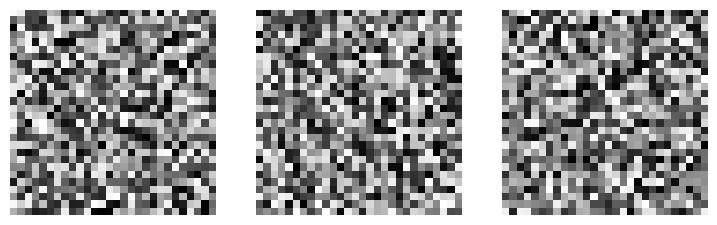

In [15]:
import matplotlib.pyplot as plt

input_image = torch.rand(3,28,28) # represents three 2D images of size 28x28
print(input_image.size())  # torch.Size([3, 28, 28])

# Here are the 'images' we generated (random noise)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i in range(3):
    axes[i].imshow(input_image[i], cmap="gray")
    axes[i].axis("off")
plt.show()

### We initialize the nn.Flatten layer to convert each 2D 28x28 image into a contiguous array of 784 pixel values (the minibatch dimension (at dim=0) is maintained).

In [16]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(f'flat_image.size() : {flat_image.size()}')

flat_image.size() : torch.Size([3, 784])


## nn.Linear
<span style='font-size:18px;'>The linear layer is a module that applies a linear transformation on the input using its stored weights and biases.</span>

In [17]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(f'hidden1.size: {hidden1.size()}')

hidden1.size: torch.Size([3, 20])


## nn.ReLU
<span style='font-size:18px;'>Non-linear activations are what create the complex mappings between the model’s inputs and outputs. They are applied after linear transformations to introduce nonlinearity, helping neural networks learn a wide variety of phenomena.<br><br>
In this model, we use nn.ReLU between our linear layers, but there are other activations to introduce non-linearity in your model.</span>

In [18]:
print(f"Before ReLU: {hidden1}\n\n")

hidden1 = nn.ReLU()(hidden1)
print(f"\nAfter ReLU: {hidden1}")

Before ReLU: tensor([[ 2.1275e-02, -1.0119e-01,  1.6249e-01, -6.1109e-02,  4.2837e-02,
          3.2485e-01,  1.3010e-01, -2.5484e-01, -2.7985e-01,  3.6876e-01,
          1.1815e-01,  2.6906e-02,  2.8824e-02,  5.7887e-01, -4.2652e-01,
          2.6590e-01, -4.0822e-02,  4.4853e-02, -1.1337e-01,  2.1190e-01],
        [ 2.1380e-02, -1.0998e-01,  4.8923e-01, -1.5581e-01,  1.8778e-01,
         -5.9746e-02, -3.0576e-01, -3.5192e-02, -6.3371e-01, -2.7732e-01,
         -8.4605e-02,  1.8517e-01,  2.3172e-01,  5.6839e-01, -1.8816e-01,
          4.7119e-01, -9.7622e-02, -9.8447e-02, -1.8069e-01,  1.6642e-01],
        [ 1.4934e-01, -2.4681e-01,  2.2583e-01, -2.3061e-01, -2.4441e-01,
         -2.4001e-04, -2.1848e-01, -5.3098e-01, -2.4116e-01,  3.3508e-01,
         -2.8014e-01,  2.7824e-01,  2.6429e-01,  3.4087e-01, -6.2538e-01,
          3.1626e-01, -1.1855e-01,  1.1016e-02, -3.3277e-01,  2.7557e-01]],
       grad_fn=<AddmmBackward0>)



After ReLU: tensor([[0.0213, 0.0000, 0.1625, 0.0000, 0.0428

## nn.Sequential
<span style='font-size:18px;'>nn.Sequential is an ordered container of modules. The data is passed through all the modules in the same order as defined.<br><br>
You can use sequential containers to put together a quick network like seq_modules.</span>

In [20]:
# quick network
seq_modules = nn.Sequential( 
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)

input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

print(f'logits:\n{logits}')

logits:
tensor([[ 0.0800,  0.1200, -0.0783, -0.0465,  0.0794,  0.1083, -0.0893, -0.0504,
         -0.1350, -0.1283],
        [ 0.1415,  0.0961, -0.1497, -0.1239,  0.0265,  0.0978, -0.0649, -0.2297,
         -0.0270, -0.1350],
        [ 0.1266,  0.0756, -0.1193, -0.1327,  0.0493,  0.1223, -0.0862, -0.1896,
         -0.0807, -0.2107]], grad_fn=<AddmmBackward0>)


## nn.Softmax
<span style='font-size:18px;'>
The last linear layer of the neural network returns logits - raw values in [-infty, infty] - which are passed to the nn.Softmax module. <br><br>
The logits are scaled to values [0, 1] representing the model’s predicted probabilities for each class. <br><br>
The 'dim' parameter indicates the dimension along which the values must sum to 1</span>

In [32]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
print(f'pred_probab:\n{pred_probab}')
print(f'pred_probab.shape: {pred_probab.shape}')
print(f'pred_probab[0].shape: {pred_probab[0].shape}')
print(f'ex: pred_probab[0] sums to: {pred_probab[0].sum()}') # all 10 elts sum to 1

pred_probab:
tensor([[0.1094, 0.1138, 0.0934, 0.0964, 0.1093, 0.1125, 0.0923, 0.0960, 0.0882,
         0.0888],
        [0.1187, 0.1134, 0.0887, 0.0910, 0.1058, 0.1136, 0.0966, 0.0819, 0.1003,
         0.0900],
        [0.1178, 0.1119, 0.0921, 0.0909, 0.1090, 0.1173, 0.0952, 0.0859, 0.0957,
         0.0841]], grad_fn=<SoftmaxBackward0>)
pred_probab.shape: torch.Size([3, 10])
pred_probab[0].shape: torch.Size([10])
ex: pred_probab[0] sums to: 1.0


## Model Parameters

<span style='font-size:18px;'>
Many layers inside a neural network are parameterized, i.e. have associated weights and biases that are optimized during training. <br><br>
Subclassing nn.Module automatically tracks all fields defined inside your model object, and makes all parameters accessible using your model’s parameters() or named_parameters() methods.<br><br>
In this example, we iterate over each parameter, and print its size and a preview of its values.</span>

In [33]:
print("Model structure: ", model, "\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure:  NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
) 


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0069,  0.0163,  0.0350,  ..., -0.0127,  0.0170, -0.0067],
        [-0.0105,  0.0165, -0.0056,  ...,  0.0172, -0.0143,  0.0328]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([-0.0037,  0.0351], grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0201, -0.0187,  0.0016,  ...,  0.0354,  0.0157, -0.0243],
        [-0.0380, -0.0074,  0.0373,  ..., -0.0198,  0.0060, -0.0442]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.bias 

## Backpropagation

<span style='font-size:18px;'>
When training neural networks, the most frequently used algorithm is backpropagation. In this algorithm, parameters (model weights) are adjusted according to the gradient of the loss function with respect to the given parameter.<br><br>
To compute those gradients, PyTorch has a built-in differentiation engine called torch.autograd. It supports automatic computation of gradient for any computational graph.</span>

#### Consider the simplest one-layer neural network, with input x, parameters w and b, and some loss function. It can be defined in PyTorch in the following manner:

In [40]:
import torch

x = torch.ones(5)  # input tensor
print(f'input tensor: {x}')
y = torch.zeros(3)  # expected output
print(f'expected output: {y}\n')

w = torch.randn(5, 3, requires_grad=True) # weights 
print(f'weights: {w}')
print(f'weights shape: {w.shape}\n')

b = torch.randn(3, requires_grad=True) # biases
print(f'biases: {b}\n')

z = torch.matmul(x, w)+b # wx + b, actual output
print(f'actual output: {z}\n')

loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y) 
# compare z = wx + b with expected output y
print(f'loss: {loss}')

input tensor: tensor([1., 1., 1., 1., 1.])
expected output: tensor([0., 0., 0.])

weights: tensor([[ 0.1435, -0.2338, -0.1999],
        [-1.3962, -0.0641,  1.3868],
        [-1.0447, -1.8195,  2.3948],
        [-0.2768, -0.1100,  0.9573],
        [ 1.0555, -0.4510, -0.4885]], requires_grad=True)
weights shape: torch.Size([5, 3])

biases: tensor([-0.4582, -0.1579, -0.7054], requires_grad=True)

actual output: tensor([-1.9769, -2.8362,  3.3452], grad_fn=<AddBackward0>)

loss: 1.1888394355773926


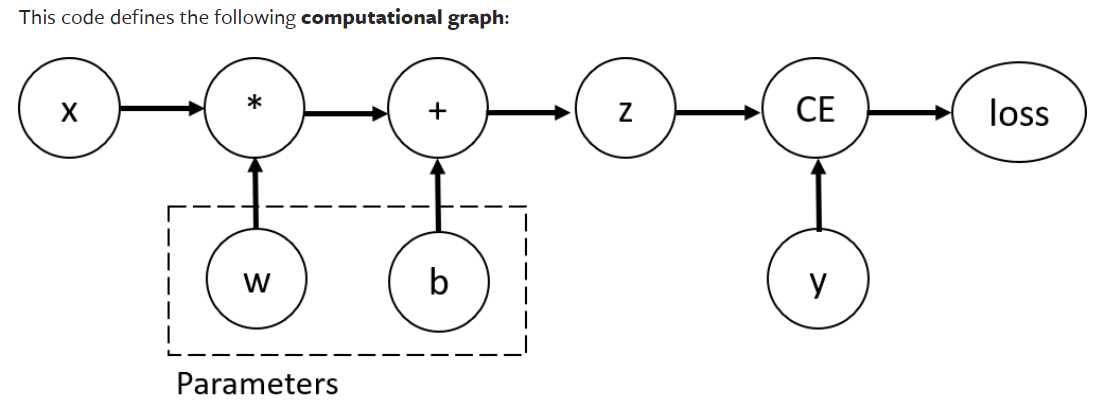

<span style='font-size:18px;'>In this network, w and b are parameters, which we need to optimize. Thus, we need to be able to compute the gradients of loss function with respect to those variables. In order to do that, we set the requires_grad property of those tensors.</span>

<span style='font-size:18px;'>A function that we apply to tensors to construct a computational graph is in fact an object of class Function.<br><br>
This object knows how to compute the function in the forward direction, and also how to compute its derivative during the backward propagation step.<br><br>
A reference to the backward propagation function is stored in grad_fn property of a tensor. You can find more information of Function in the documentation.</span>

## LSTM in PyTorch

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1) # for reproducibility
np.random.seed(1)

In [ ]:
lstm = nn.LSTM(3, 3)  # Input dim is 3, output dim is 3

inputs = [torch.randn(1, 3) for _ in range(20)]  # make a sequence of length 20

# initialize the hidden state.
hidden = [torch.randn(1, 1, 3)] * 100
for i in inputs:
    # Step through the sequence one element at a time.
    # after each step, hidden contains the hidden state.
    out, hidden = lstm(i.view(1, 1, -1), hidden)

# alternatively, we can do the entire sequence all at once.
# the first value returned by LSTM is all of the hidden states throughout
# the sequence. the second is just the most recent hidden state
# (compare the last slice of "out" with "hidden" below, they are the same)

# The reason for this is that:
# "out" will give you access to all hidden states in the sequence
# "hidden" will allow you to continue the sequence and backpropagate,
# by passing it as an argument  to the lstm at a later time
# Add the extra 2nd dimension

inputs = torch.cat(inputs).view(len(inputs), 1, -1)
hidden = [torch.randn(1, 1, 3)] * 100  # clean out hidden state
out, hidden = lstm(inputs, hidden)

print(f'out.shape: {out.size()}\nout: {out}\n')
print(f'hidden: {hidden}')

out.shape: torch.Size([5, 1, 3])
out: tensor([[[-0.0187,  0.1713, -0.2944]],

        [[-0.3521,  0.1026, -0.2971]],

        [[-0.3191,  0.0781, -0.1957]],

        [[-0.1634,  0.0941, -0.1637]],

        [[-0.3368,  0.0959, -0.0538]]], grad_fn=<MkldnnRnnLayerBackward0>)

hidden: (tensor([[[-0.3368,  0.0959, -0.0538]]], grad_fn=<StackBackward0>), tensor([[[-0.9825,  0.4715, -0.0633]]], grad_fn=<StackBackward0>))


## Does it seem fuzzy?

<span style='font-size:18px;'>Here is a sample LSTM model in Pytorch using ```nn.LSTM```:</span>

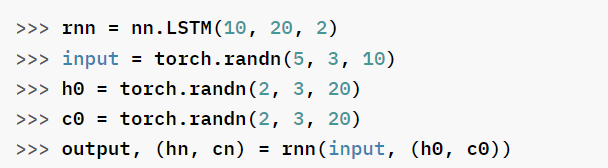

(example only, not runnable code)

<span style='font-size:18px;'>Here is a sample LSTM model in Keras. There are some simiarities: </span>

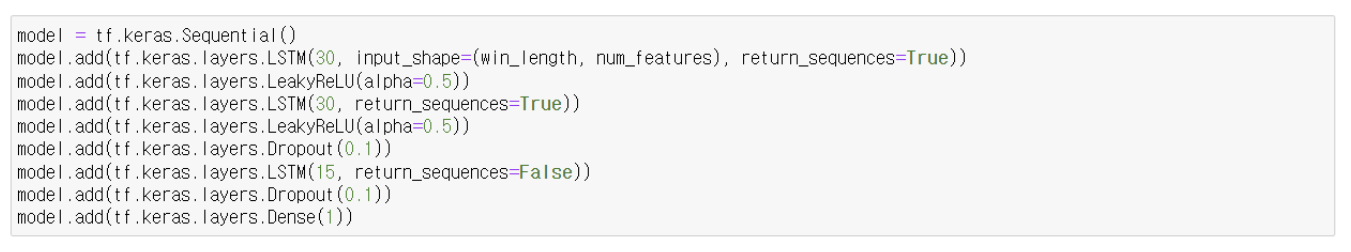

(example only, not runnable code)

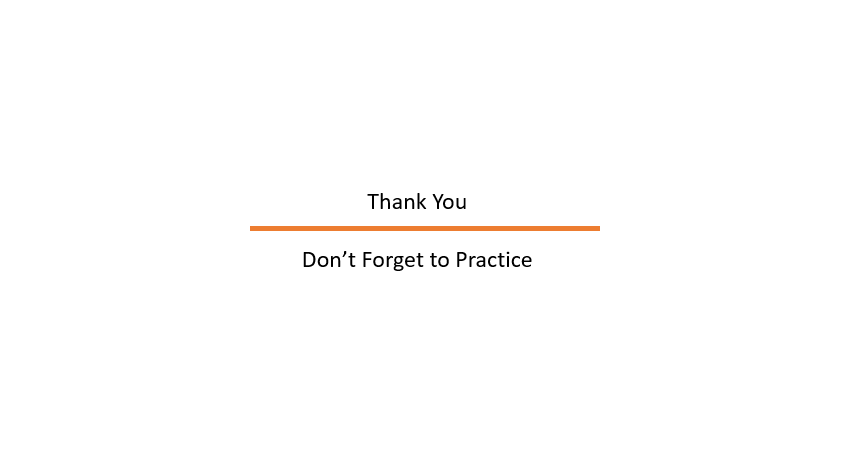